## Problema do fluxo máximo

In [1]:
%pip install pulp -q

import pulp

prob = pulp.LpProblem("Fluxo_Maximo", pulp.LpMaximize)

# Variaveis de fluxo para cada arco
f_s_v1 = pulp.LpVariable("f_s_v1", lowBound=0, cat='Continuous')
f_s_v2 = pulp.LpVariable("f_s_v2", lowBound=0, cat='Continuous')
f_s_v3 = pulp.LpVariable("f_s_v3", lowBound=0, cat='Continuous')
f_v1_v2 = pulp.LpVariable("f_v1_v2", lowBound=0, cat='Continuous')
f_v2_v3 = pulp.LpVariable("f_v2_v3", lowBound=0, cat='Continuous')
f_v1_v4 = pulp.LpVariable("f_v1_v4", lowBound=0, cat='Continuous')
f_v1_v5 = pulp.LpVariable("f_v1_v5", lowBound=0, cat='Continuous')
f_v2_v5 = pulp.LpVariable("f_v2_v5", lowBound=0, cat='Continuous')
f_v3_v5 = pulp.LpVariable("f_v3_v5", lowBound=0, cat='Continuous')
f_v3_v6 = pulp.LpVariable("f_v3_v6", lowBound=0, cat='Continuous')
f_v4_t = pulp.LpVariable("f_v4_t", lowBound=0, cat='Continuous')
f_v5_v4 = pulp.LpVariable("f_v5_v4", lowBound=0, cat='Continuous')
f_v5_t = pulp.LpVariable("f_v5_t", lowBound=0, cat='Continuous')
f_v6_v5 = pulp.LpVariable("f_v6_v5", lowBound=0, cat='Continuous')
f_v6_t = pulp.LpVariable("f_v6_t", lowBound=0, cat='Continuous')

# Capacidades
prob += f_s_v1 <= 5
prob += f_s_v2 <= 4
prob += f_s_v3 <= 6
prob += f_v1_v2 <= 4
prob += f_v2_v3 <= 3
prob += f_v1_v4 <= 6
prob += f_v1_v5 <= 5
prob += f_v2_v5 <= 4
prob += f_v3_v5 <= 6
prob += f_v3_v6 <= 5
prob += f_v4_t <= 5
prob += f_v5_v4 <= 5
prob += f_v5_t <= 3
prob += f_v6_v5 <= 7
prob += f_v6_t <= 6

# Conserv. dos nos intermediarios
# v1: entra: s->v1; Sai = v1->v2, v1->v4 + v1->v5
prob += f_s_v1 == f_v1_v2 + f_v1_v4 + f_v1_v5

# v2: entra: s->v2, v1->v2; sai: v2->v3, v2->v5
prob += f_s_v2 + f_v1_v2 == f_v2_v3 + f_v2_v5

# v3: entra: s->v3, v2->v3; sai: v3->v5, v3->v6
prob += f_s_v3 + f_v2_v3 == f_v3_v5 + f_v3_v6

# v4: entra: v1->v4, v5->v4; sai: v4->t
prob += f_v1_v4 + f_v5_v4 == f_v4_t

# v5: entra: v1->v5, v2->v5, v3->v5, v6->v5; sai: v5->v4, v5->t
prob += f_v1_v5 + f_v2_v5 + f_v3_v5 + f_v6_v5 == f_v5_v4 + f_v5_t

# v6: entra: v3->v6; sai: v6->v5, v6->t
prob += f_v3_v6 == f_v6_v5 + f_v6_t

# Funcao obj: max fluxo que sai de s (ou entra em t)
fluxo_total = f_s_v1 + f_s_v2 + f_s_v3
prob += fluxo_total

prob.solve(pulp.PULP_CBC_CMD(msg=False))

print("\nPROBLEMA DO FLUXO MÁXIMO\n")
print(f"Fluxo máximo de s para t = {pulp.value(fluxo_total):.0f}\n")

print("Fluxos em cada arco:")
print(f" s -> v1: {f_s_v1.varValue:.0f} (cap 5)")
print(f" s -> v2: {f_s_v2.varValue:.0f} (cap 4)")
print(f" s -> v3: {f_s_v3.varValue:.0f} (cap 6)")
print(f"v1 -> v2: {f_v1_v2.varValue:.0f} (cap 4)")
print(f"v1 -> v4: {f_v1_v4.varValue:.0f} (cap 6)")
print(f"v1 -> v5: {f_v1_v5.varValue:.0f} (cap 5)")
print(f"v2 -> v3: {f_v2_v3.varValue:.0f} (cap 3)")
print(f"v2 -> v5: {f_v2_v5.varValue:.0f} (cap 4)")
print(f"v3 -> v5: {f_v3_v5.varValue:.0f} (cap 6)")
print(f"v3 -> v6: {f_v3_v6.varValue:.0f} (cap 5)")
print(f"v4 ->  t: {f_v4_t.varValue:.0f} (cap 5)")
print(f"v5 -> v4: {f_v5_v4.varValue:.0f} (cap 5)")
print(f"v5 ->  t: {f_v5_t.varValue:.0f} (cap 3)")
print(f"v6 -> v5: {f_v6_v5.varValue:.0f} (cap 7)")
print(f"v6 ->  t: {f_v6_t.varValue:.0f} (cap 6)")

Note: you may need to restart the kernel to use updated packages.

PROBLEMA DO FLUXO MÁXIMO

Fluxo máximo de s para t = 13

Fluxos em cada arco:
 s -> v1: 3 (cap 5)
 s -> v2: 4 (cap 4)
 s -> v3: 6 (cap 6)
v1 -> v2: 0 (cap 4)
v1 -> v4: 3 (cap 6)
v1 -> v5: 0 (cap 5)
v2 -> v3: 0 (cap 3)
v2 -> v5: 4 (cap 4)
v3 -> v5: 1 (cap 6)
v3 -> v6: 5 (cap 5)
v4 ->  t: 5 (cap 5)
v5 -> v4: 2 (cap 5)
v5 ->  t: 3 (cap 3)
v6 -> v5: 0 (cap 7)
v6 ->  t: 5 (cap 6)


Note: you may need to restart the kernel to use updated packages.


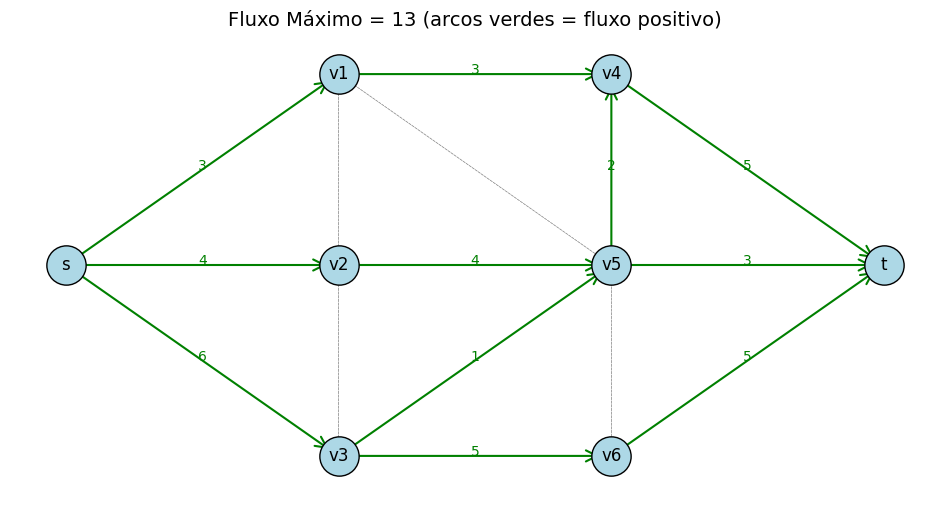

In [2]:
%pip install networkx matplotlib -q

import networkx as nx
import matplotlib.pyplot as plt

# Grafo direcionado
G = nx.DiGraph()

# Arcos com capacidades
arestas = [
  ('s', 'v1', 5), ('s', 'v2', 4), ('s', 'v3', 6),
  ('v1', 'v2', 4), ('v1', 'v4', 6), ('v1', 'v5', 5),
  ('v2', 'v3', 3), ('v2', 'v5', 4),
  ('v3', 'v5', 6), ('v3', 'v6', 5),
  ('v4', 't', 5),
  ('v5', 'v4', 5), ('v5', 't', 3),
  ('v6', 'v5', 7), ('v6', 't', 6)
]

for u, v, cap in arestas:
  G.add_edge(u, v, capacity=cap)

fluxos_positivos = {
  ('s', 'v1'): 3,
  ('s', 'v2'): 4,
  ('s', 'v3'): 6,
  ('v1', 'v4'): 3,
  ('v2', 'v5'): 4,
  ('v3', 'v5'): 1,
  ('v3', 'v6'): 5,
  ('v4', 't'): 5,
  ('v5', 'v4'): 2,
  ('v5', 't'): 3,
  ('v6', 't'): 5,
}

# Posicionando os nos para o grafico
pos = {
  's': (0, 0.5),
  'v1': (2, 1),
  'v2': (2, 0.5),
  'v3': (2, 0),
  'v4': (4, 1),
  'v5': (4, 0.5),
  'v6': (4, 0),
  't': (6, 0.5)
}

plt.figure(figsize=(12, 6))

# Desenhando todos os nós
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='lightblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=12)

# Desenhando apenas os arcos com fluxo positivo
for (u, v), fl in fluxos_positivos.items():
  nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=1.5, edge_color='green', arrows=True, arrowsize=20, arrowstyle='->')
  # Rotulo com o fluxo
  plt.text((pos[u][0] + pos[v][0])/2, (pos[u][1] + pos[v][1])/2, str(fl), color='green', fontsize=10, ha='center')

# Desenhando arcos com fluxo zero
arcos_zero = [(u, v) for u, v, cap in arestas if (u, v) not in fluxos_positivos]
if arcos_zero:
  nx.draw_networkx_edges(G, pos, edgelist=arcos_zero, width=0.5, edge_color='gray', style='dashed', arrows=True, arrowsize=10)

plt.title("Fluxo Máximo = 13 (arcos verdes = fluxo positivo)", fontsize=14)
plt.axis('off')
plt.show()